In [6]:
import pandas as pd
import numpy as np

In [28]:
# Set display options for clean output
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None
# # Configures pandas to display more columns without wrapping
# pd.options.display.width = 1000
# pd.options.display.expand_frame_repr = False
pd.options.display.max_colwidth = 35

In [48]:
import pandas as pd

# Load samples
articles_sample = pd.read_csv('../data/raw/articles.csv', nrows=10)
transactions_sample = pd.read_csv('../data/raw/transactions_train.csv', nrows=10)

print("=" * 60)
print("ARTICLES.CSV - ALL COLUMNS")
print("=" * 60)
# Transpose so columns become rows - much easier to read
print(articles_sample.head(2).T)

print("\n" + "=" * 60)
print("TRANSACTIONS.CSV - ALL COLUMNS")
print("=" * 60)
print(transactions_sample.head(2).T)

ARTICLES.CSV - ALL COLUMNS
                                                               0                                   1
article_id                                             108775015                           108775044
product_code                                              108775                              108775
prod_name                                              Strap top                           Strap top
product_type_no                                              253                                 253
product_type_name                                       Vest top                            Vest top
product_group_name                            Garment Upper body                  Garment Upper body
graphical_appearance_no                                  1010016                             1010016
graphical_appearance_name                                  Solid                               Solid
colour_group_code                                              9

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load full articles (only 105K rows, totally manageable)
articles = pd.read_csv('../data/raw/articles.csv')
print(f"Articles loaded: {len(articles):,} products")

# Load a systematic sample of transactions (every 60th row = ~500K transactions)
# This is enough to see patterns without killing memory
transactions = pd.read_csv('../data/raw/transactions_train.csv',
                          skiprows=lambda i: i > 0 and i % 60 != 0)
print(f"Transactions sampled: {len(transactions):,} purchases")
print(f"(About {len(transactions)/31000000*100:.1f}% of full dataset)")

print("\n" + "=" * 60)
print("WHAT CATEGORIES EXIST IN ARTICLES?")
print("=" * 60)
print(articles['index_name'].value_counts())

print("\n" + "=" * 60)
print("SAMPLE OF TRANSACTIONS")
print("=" * 60)
print(transactions.head())

LOADING DATA
Articles loaded: 105,542 products
Transactions sampled: 529,805 purchases
(About 1.7% of full dataset)

WHAT CATEGORIES EXIST IN ARTICLES?
index_name
Ladieswear                        26001
Divided                           15149
Menswear                          12553
Children Sizes 92-140             12007
Children Sizes 134-170             9214
Baby Sizes 50-98                   8875
Ladies Accessories                 6961
Lingeries/Tights                   6775
Children Accessories, Swimwear     4615
Sport                              3392
Name: count, dtype: int64

SAMPLE OF TRANSACTIONS
        t_dat                         customer_id  article_id  price  sales_channel_id
0  2018-09-20  003ac6eff3ca20cbe4e14a106a5e28b...   620405001   0.02                 1
1  2018-09-20  0095c9b47fc950788bb709201f024c5...   633130019   0.02                 1
2  2018-09-20  00e66bb584bb15b519d91b1979bc7ba...   633861001   0.04                 2
3  2018-09-20  014cbfc591254f0cf30df52b

In [36]:
print("=" * 60)
print("MERGING TRANSACTIONS WITH PRODUCT CATEGORIES")
print("=" * 60)

# Merge to get category for each transaction
# Keep only the columns we need to save memory
articles_slim = articles[['article_id', 'index_name']]
sales_with_category = transactions.merge(articles_slim, on='article_id', how='left')

print(f"Merged successfully: {len(sales_with_category):,} transactions")
print(f"Any transactions without category match: {sales_with_category['index_name'].isna().sum()}")

print("\n" + "=" * 60)
print("SALES COUNT BY CATEGORY")
print("=" * 60)

# Count how many items sold in each category
category_sales = sales_with_category['index_name'].value_counts()
print(category_sales)

print("\n" + "=" * 60)
print("AS PERCENTAGES")
print("=" * 60)
category_pct = (category_sales / category_sales.sum() * 100).round(1)
for cat, pct in category_pct.items():
    print(f"{cat:35} {category_sales[cat]:>8,} ({pct:>5.1f}%)")

MERGING TRANSACTIONS WITH PRODUCT CATEGORIES
Merged successfully: 529,805 transactions
Any transactions without category match: 0

SALES COUNT BY CATEGORY
index_name
Ladieswear                        217569
Divided                           119069
Lingeries/Tights                   93091
Ladies Accessories                 29526
Menswear                           29485
Sport                              20821
Children Sizes 134-170              8262
Children Sizes 92-140               5860
Baby Sizes 50-98                    4258
Children Accessories, Swimwear      1864
Name: count, dtype: int64

AS PERCENTAGES
Ladieswear                           217,569 ( 41.1%)
Divided                              119,069 ( 22.5%)
Lingeries/Tights                      93,091 ( 17.6%)
Ladies Accessories                    29,526 (  5.6%)
Menswear                              29,485 (  5.6%)
Sport                                 20,821 (  3.9%)
Children Sizes 134-170                 8,262 (  1.6%)
Chil

Creating visualization (fixed version)...
Saved to: ../visualizations/day2_category_sales.png


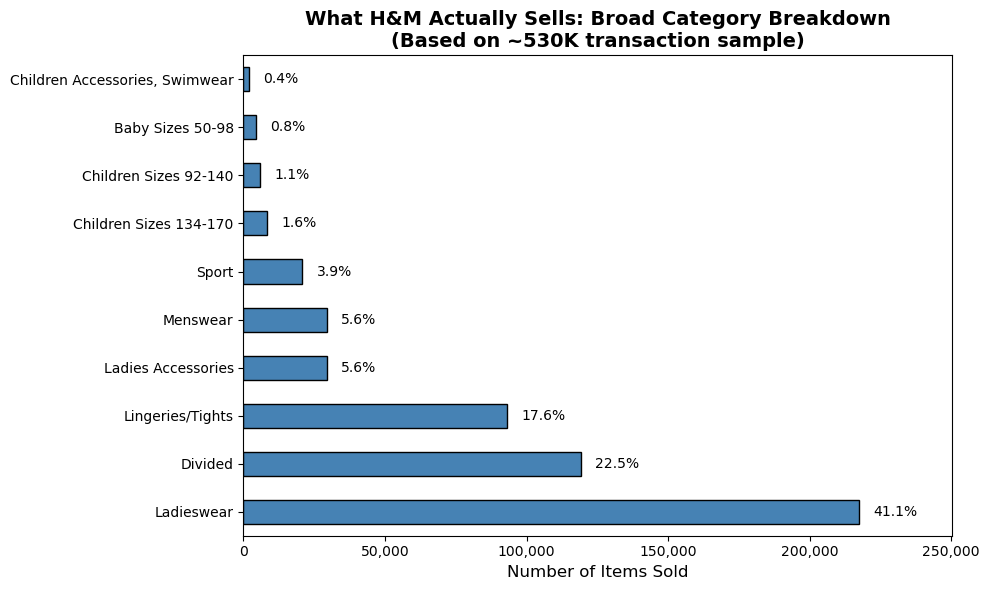

In [42]:
import matplotlib.pyplot as plt

print("Creating visualization (fixed version)...")

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
category_sales.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')

# Format
ax.set_xlabel('Number of Items Sold', fontsize=12)
ax.set_ylabel('')
ax.set_title("What H&M Actually Sells: Broad Category Breakdown\n(Based on ~530K transaction sample)", 
             fontsize=14, fontweight='bold')

# Add percentage labels on bars
for i, (cat, count) in enumerate(category_sales.items()):
    pct = count / category_sales.sum() * 100
    ax.text(count + 5000, i, f'{pct:.1f}%', va='center', fontsize=10)

# Format x-axis with commas
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# FIX: Extend x-axis limit to make room for the label
ax.set_xlim(0, category_sales.max() * 1.15)  # Add 15% padding

# Tight layout
plt.tight_layout()

# Save
plt.savefig('../visualizations/day2_category_sales.png', dpi=300, bbox_inches='tight')
print("Saved to: ../visualizations/day2_category_sales.png")

plt.show()

H&M's sales are overwhelmingly concentrated in women's categories, with Ladieswear (41.1%), Divided (22.5%), and Lingeries/Tights (17.6%) accounting for 81.2% of all transactions. Menswear represents only 5.6% of sales—roughly equal to Ladies Accessories alone—while children's and sport categories combined make up less than 10%. This data reveals H&M's customer base and business model are heavily skewed toward female shoppers, with the younger-targeted Divided line representing nearly a quarter of all sales.